# Amazon Sales Dataset

In [1]:
#1
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert the 'rating' column to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Calculate the average rating by category
average_rating_by_category = df.groupby('category')['rating'].mean().reset_index()
print("Average Rating by Category:\n", average_rating_by_category)


Average Rating by Category:
                                               category    rating
0    Car&Motorbike|CarAccessories|InteriorAccessori...  3.800000
1    Computers&Accessories|Accessories&Peripherals|...  4.150000
2    Computers&Accessories|Accessories&Peripherals|...  3.500000
3    Computers&Accessories|Accessories&Peripherals|...  3.600000
4    Computers&Accessories|Accessories&Peripherals|...  4.050000
..                                                 ...       ...
206  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.250000
207  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.150000
208  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.300000
209  OfficeProducts|OfficePaperProducts|Paper|Stati...  4.133333
210  Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...  4.300000

[211 rows x 2 columns]


In [2]:
#2
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert the 'rating_count' column to numeric
df['rating_count'] = df['rating_count'].replace({',':''}, regex=True).astype(float)

# Find the top rated products by category
top_rated_products = df.loc[df.groupby('category')['rating_count'].idxmax()][['category', 'product_name', 'rating', 'rating_count']]
print("Top Rated Products by Category:\n", top_rated_products)


Top Rated Products by Category:
                                                category  \
1157  Car&Motorbike|CarAccessories|InteriorAccessori...   
695   Computers&Accessories|Accessories&Peripherals|...   
906   Computers&Accessories|Accessories&Peripherals|...   
748   Computers&Accessories|Accessories&Peripherals|...   
844   Computers&Accessories|Accessories&Peripherals|...   
...                                                 ...   
616   OfficeProducts|OfficePaperProducts|Paper|Stati...   
993   OfficeProducts|OfficePaperProducts|Paper|Stati...   
765   OfficeProducts|OfficePaperProducts|Paper|Stati...   
850   OfficeProducts|OfficePaperProducts|Paper|Stati...   
924   Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...   

                                           product_name rating  rating_count  
1157  Reffair AX30 [MAX] Portable Air Purifier for C...    3.8        1118.0  
695   rts [2 Pack] Mini USB C Type C Adapter Plug, T...    4.3        4426.0  
906   Hp Wired On Ear

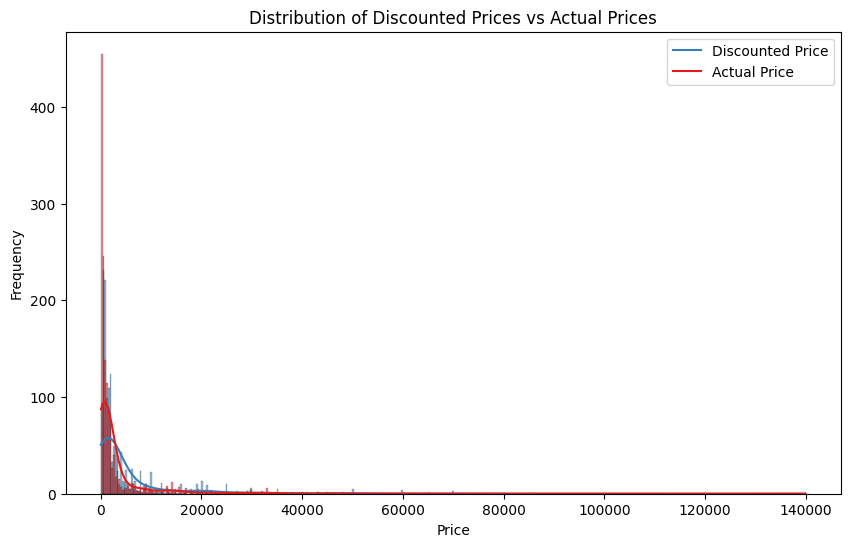

In [3]:
#3
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert price columns to numeric
df['discounted_price'] = df['discounted_price'].replace({'₹':'', ',':''}, regex=True).astype(float)
df['actual_price'] = df['actual_price'].replace({'₹':'', ',':''}, regex=True).astype(float)

# Plot the distribution
plt.figure(figsize=(10, 6))
sns.histplot(df[['discounted_price', 'actual_price']], kde=True, palette="Set1")
plt.title('Distribution of Discounted Prices vs Actual Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.legend(['Discounted Price', 'Actual Price'])
plt.show()


In [4]:
#4
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert 'discount_percentage' to numeric
df['discount_percentage'] = df['discount_percentage'].replace({'%':'', ',':''}, regex=True).astype(float)

# Calculate the average discount by category
average_discount_by_category = df.groupby('category')['discount_percentage'].mean().reset_index()
print("Average Discount Percentage by Category:\n", average_discount_by_category)


Average Discount Percentage by Category:
                                               category  discount_percentage
0    Car&Motorbike|CarAccessories|InteriorAccessori...                 42.0
1    Computers&Accessories|Accessories&Peripherals|...                 78.5
2    Computers&Accessories|Accessories&Peripherals|...                 35.0
3    Computers&Accessories|Accessories&Peripherals|...                 56.5
4    Computers&Accessories|Accessories&Peripherals|...                 46.5
..                                                 ...                  ...
206  OfficeProducts|OfficePaperProducts|Paper|Stati...                  0.0
207  OfficeProducts|OfficePaperProducts|Paper|Stati...                  5.0
208  OfficeProducts|OfficePaperProducts|Paper|Stati...                 17.5
209  OfficeProducts|OfficePaperProducts|Paper|Stati...                 13.0
210  Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...                  0.0

[211 rows x 2 columns]


In [5]:
#5
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert 'rating_count' to numeric
df['rating_count'] = df['rating_count'].replace({',':''}, regex=True).astype(float)

# Find the most popular products by rating count
most_popular_products = df.sort_values('rating_count', ascending=False)[['product_name', 'rating_count']].head(10)
print("Most Popular Products by Rating Count:\n", most_popular_products)


Most Popular Products by Rating Count:
                                           product_name  rating_count
12   AmazonBasics Flexible Premium HDMI Cable (Blac...      426973.0
65   Amazon Basics High-Speed HDMI Cable, 6 Feet (2...      426973.0
47   Amazon Basics High-Speed HDMI Cable, 6 Feet - ...      426973.0
684  AmazonBasics Flexible Premium HDMI Cable (Blac...      426972.0
400  boAt Bassheads 100 in Ear Wired Earphones with...      363713.0
352  boAt Bassheads 100 in Ear Wired Earphones with...      363713.0
584  boAt BassHeads 100 in-Ear Wired Headphones wit...      363711.0
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...      313836.0
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...      313836.0
473  Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...      313832.0


In [6]:
#6
import pandas as pd
from collections import Counter

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Combine all product names into a single string
all_product_names = ' '.join(df['product_name'])

# Split the string into individual words
words = all_product_names.split()

# Count the frequency of each word
word_count = Counter(words)

# Find the most common words (keywords)
most_common_keywords = word_count.most_common(10)
print("Most Popular Product Keywords:\n", most_common_keywords)


Most Popular Product Keywords:
 [('with', 718), ('for', 614), ('|', 457), ('&', 432), ('USB', 342), ('and', 310), ('Cable', 306), ('-', 220), ('Charging', 212), ('Fast', 208)]


In [7]:
#7
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert 'rating_count' to numeric
df['rating_count'] = df['rating_count'].replace({',':''}, regex=True).astype(float)

# Find the most popular reviews based on rating count
most_popular_reviews = df.sort_values('rating_count', ascending=False)[['product_name', 'review_content']].head(10)
print("Most Popular Product Reviews:\n", most_popular_reviews)


Most Popular Product Reviews:
                                           product_name  \
12   AmazonBasics Flexible Premium HDMI Cable (Blac...   
65   Amazon Basics High-Speed HDMI Cable, 6 Feet (2...   
47   Amazon Basics High-Speed HDMI Cable, 6 Feet - ...   
684  AmazonBasics Flexible Premium HDMI Cable (Blac...   
400  boAt Bassheads 100 in Ear Wired Earphones with...   
352  boAt Bassheads 100 in Ear Wired Earphones with...   
584  boAt BassHeads 100 in-Ear Wired Headphones wit...   
370  Redmi 9 Activ (Carbon Black, 4GB RAM, 64GB Sto...   
371  Redmi 9A Sport (Coral Green, 2GB RAM, 32GB Sto...   
473  Redmi 9A Sport (Carbon Black, 2GB RAM, 32GB St...   

                                        review_content  
12   I am using it for 14 days now. The experience ...  
65   I am using it for 14 days now. The experience ...  
47   I am using it for 14 days now. The experience ...  
684  I am using it for 14 days now. The experience ...  
400  The sound quality of this earphone are r

In [8]:
#8
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert 'discounted_price' and 'rating' to numeric
df['discounted_price'] = df['discounted_price'].replace({'₹':'', ',':''}, regex=True).astype(float)
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Calculate the correlation
correlation_discount_price_rating = df[['discounted_price', 'rating']].corr()
print("Correlation between Discounted Price and Rating:\n", correlation_discount_price_rating)


Correlation between Discounted Price and Rating:
                   discounted_price    rating
discounted_price          1.000000  0.120337
rating                    0.120337  1.000000


In [9]:
#9
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert 'rating' to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Find the top 5 categories based on average rating
top_categories_by_rating = df.groupby('category')['rating'].mean().sort_values(ascending=False).head(5).reset_index()
print("Top 5 Categories by Highest Ratings:\n", top_categories_by_rating)


Top 5 Categories by Highest Ratings:
                                             category  rating
0                      Computers&Accessories|Tablets     4.6
1  Computers&Accessories|NetworkingDevices|Networ...     4.5
2   Electronics|Cameras&Photography|Accessories|Film     4.5
3  Electronics|HomeAudio|MediaStreamingDevices|St...     4.5
4  OfficeProducts|OfficeElectronics|Calculators|B...     4.5


In [10]:
#10
import pandas as pd

# Load the dataset
df = pd.read_csv('/content/amazon - amazon.csv')

# Convert relevant columns to numeric
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')
df['discount_percentage'] = df['discount_percentage'].replace({'%':'', ',':''}, regex=True).astype(float)

# Identify categories with the lowest ratings
lowest_rated_categories = df.groupby('category')['rating'].mean().sort_values().head(5).reset_index()
print("Categories with Lowest Average Ratings:\n", lowest_rated_categories)

# Identify categories with the lowest discount percentages
lowest_discount_categories = df.groupby('category')['discount_percentage'].mean().sort_values().head(5).reset_index()
print("Categories with Lowest Discount Percentages:\n", lowest_discount_categories)

# Combine insights to identify areas needing improvement
categories_needing_improvement = pd.merge(lowest_rated_categories, lowest_discount_categories, on='category', how='outer')
print("Categories Needing Improvement:\n", categories_needing_improvement)


Categories with Lowest Average Ratings:
                                             category  rating
0  Home&Kitchen|Kitchen&HomeAppliances|Coffee,Tea...     3.3
1  Computers&Accessories|Accessories&Peripherals|...     3.4
2  Computers&Accessories|Accessories&Peripherals|...     3.5
3  Electronics|HomeTheater,TV&Video|Accessories|3...     3.5
4  Computers&Accessories|Printers,Inks&Accessorie...     3.6
Categories with Lowest Discount Percentages:
                                             category  discount_percentage
0  Toys&Games|Arts&Crafts|Drawing&PaintingSupplie...                  0.0
1      Home&Kitchen|CraftMaterials|PaintingMaterials                  0.0
2  Home&Kitchen|CraftMaterials|DrawingMaterials|D...                  0.0
3  Home&Kitchen|Kitchen&HomeAppliances|SmallKitch...                  0.0
4  Electronics|HomeAudio|MediaStreamingDevices|St...                  0.0
Categories Needing Improvement:
                                             category  rating  \
0  Hom

# Spotify Dataset

In [11]:
#1
import pandas as pd

# Load the dataset
df_spotify = pd.read_csv('/content/spotify - spotify.csv')

# Check for missing values
missing_values = df_spotify.isnull().sum()
print("Missing Values:\n", missing_values)

# Check for duplicate rows
duplicate_rows = df_spotify.duplicated().sum()
print("Duplicate Rows:\n", duplicate_rows)

# Drop duplicate rows if any
df_spotify_cleaned = df_spotify.drop_duplicates()

# Ensure the dataframe is clean
df_spotify_cleaned.info()


Missing Values:
 Artist           0
Track Name       0
Popularity       0
Duration (ms)    0
Track ID         0
dtype: int64
Duplicate Rows:
 27
<class 'pandas.core.frame.DataFrame'>
Index: 413 entries, 0 to 438
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Artist         413 non-null    object
 1   Track Name     413 non-null    object
 2   Popularity     413 non-null    int64 
 3   Duration (ms)  413 non-null    int64 
 4   Track ID       413 non-null    object
dtypes: int64(2), object(3)
memory usage: 19.4+ KB


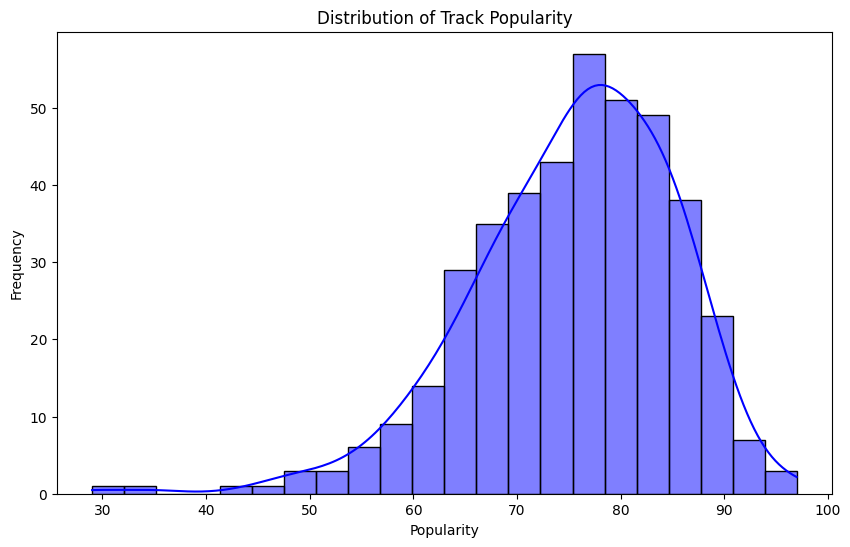

In [12]:
#2
import matplotlib.pyplot as plt
import seaborn as sns

# Plot the distribution of popularity
plt.figure(figsize=(10, 6))
sns.histplot(df_spotify_cleaned['Popularity'], kde=True, color='blue')
plt.title('Distribution of Track Popularity')
plt.xlabel('Popularity')
plt.ylabel('Frequency')
plt.show()


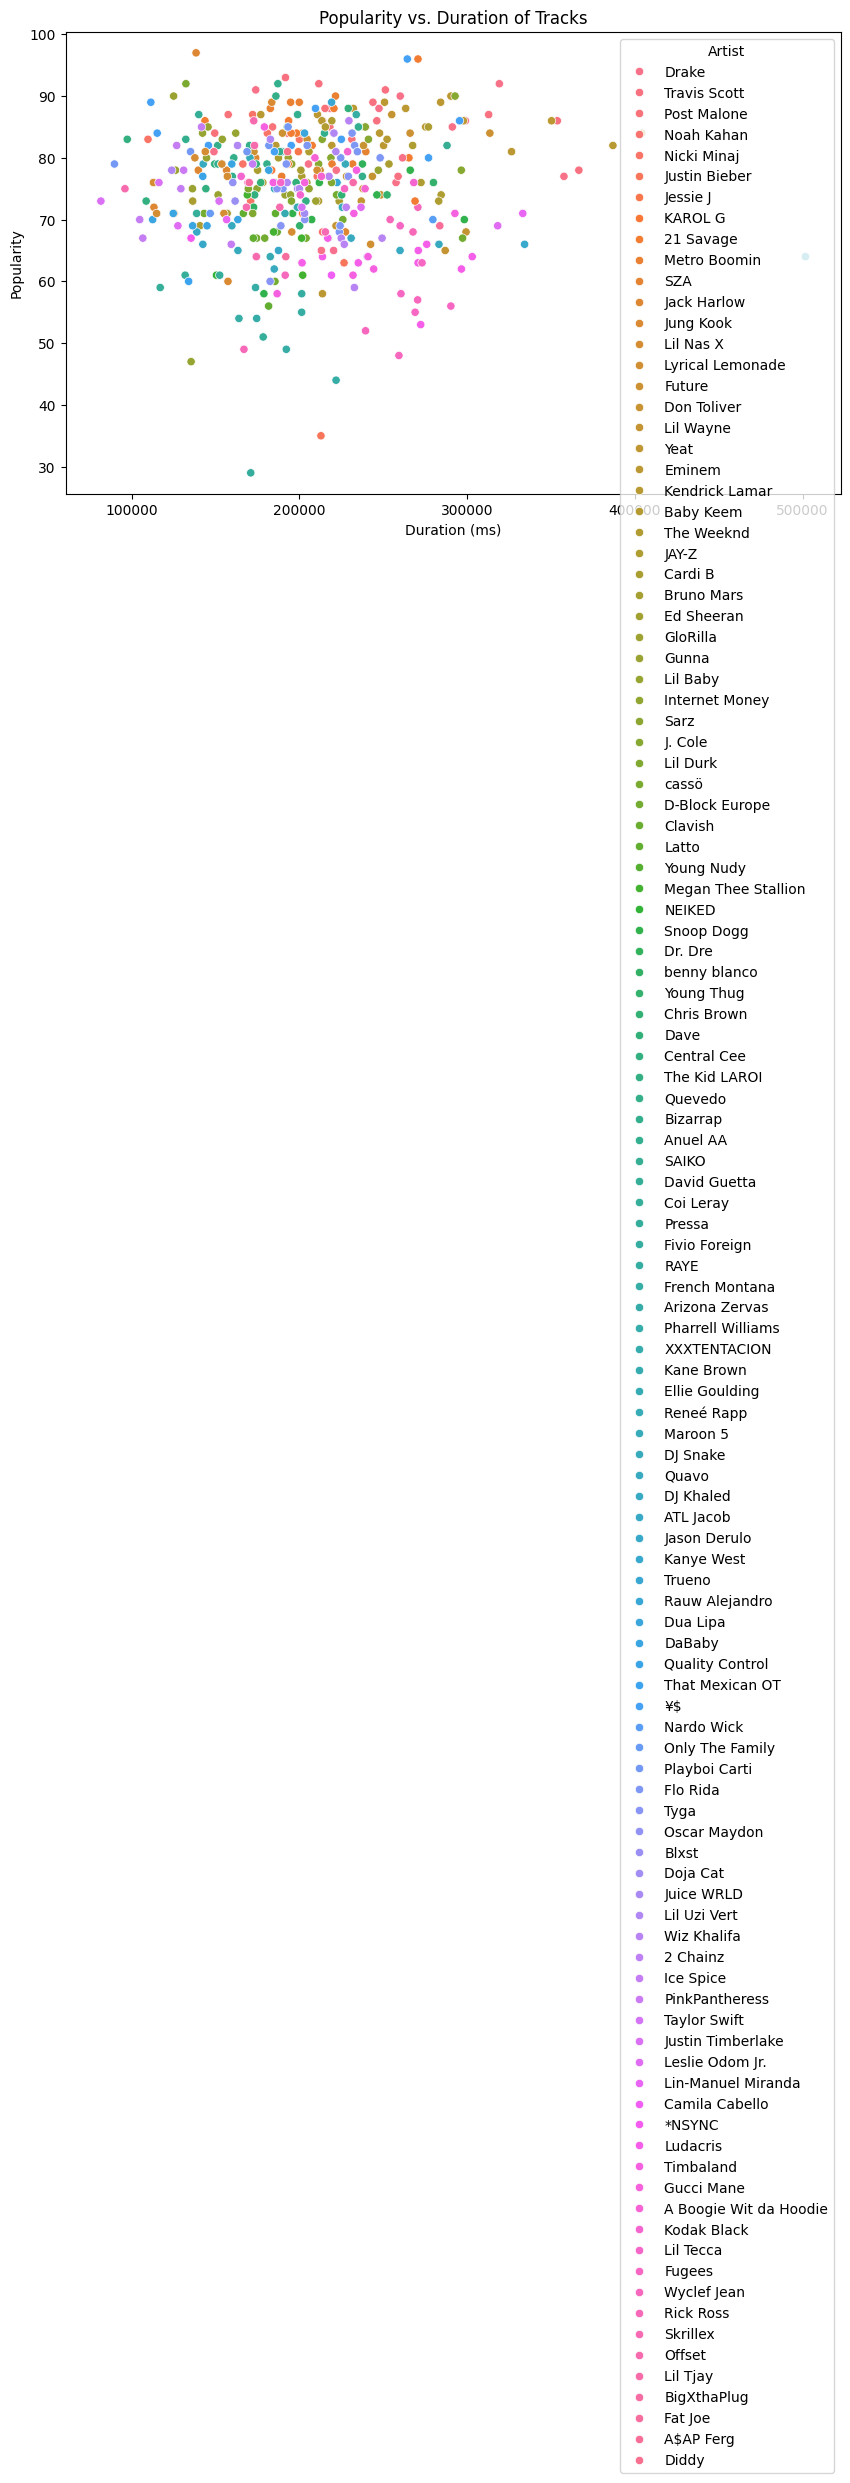

In [13]:
#3
# Plot the relationship between popularity and duration
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Duration (ms)', y='Popularity', data=df_spotify_cleaned, hue='Artist')
plt.title('Popularity vs. Duration of Tracks')
plt.xlabel('Duration (ms)')
plt.ylabel('Popularity')
plt.show()


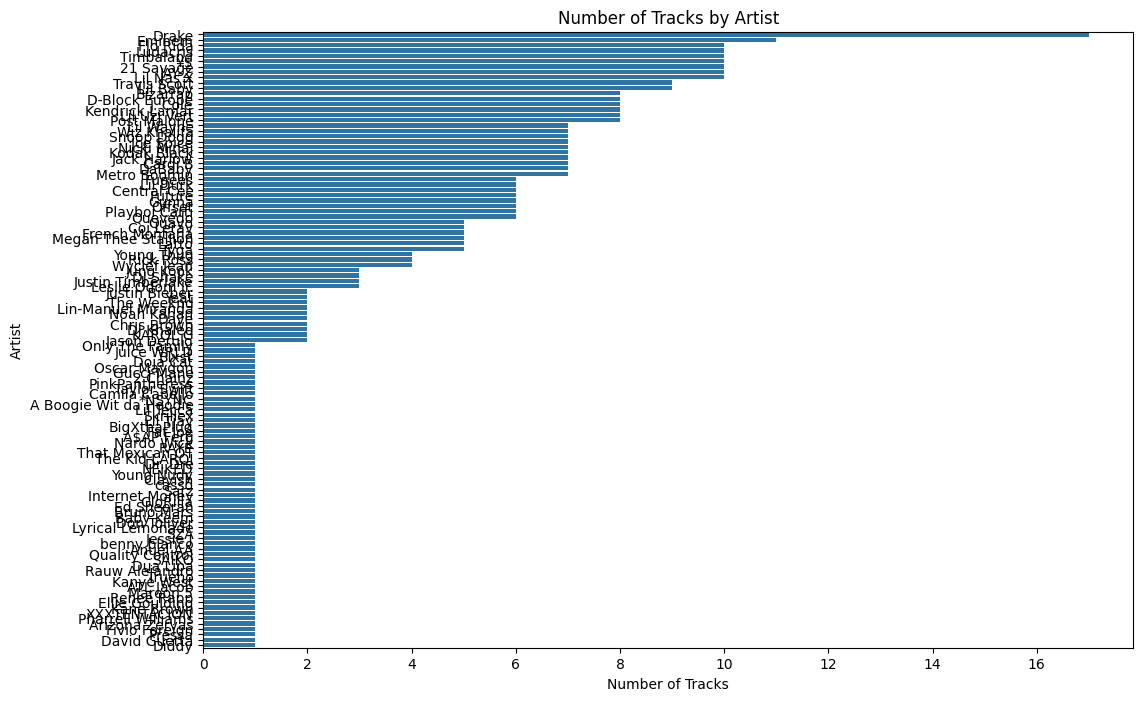

In [14]:
#4
# Count the number of tracks for each artist
plt.figure(figsize=(12, 8))
sns.countplot(y='Artist', data=df_spotify_cleaned, order=df_spotify_cleaned['Artist'].value_counts().index)
plt.title('Number of Tracks by Artist')
plt.xlabel('Number of Tracks')
plt.ylabel('Artist')
plt.show()


In [15]:
#5
# Find the top 5 least popular tracks
least_popular_tracks = df_spotify_cleaned.nsmallest(5, 'Popularity')[['Artist', 'Track Name', 'Popularity']]
print("Top 5 Least Popular Tracks:\n", least_popular_tracks)


Top 5 Least Popular Tracks:
              Artist                     Track Name  Popularity
207          Pressa  Attachments (feat. Coi Leray)          29
231   Justin Bieber                     Intentions          35
413  French Montana                Splash Brothers          44
225        Lil Baby                  On Me - Remix          47
407     Wyclef Jean      911 (feat. Mary J. Blige)          48


In [16]:
#6
# Find the top 5 most popular artists by track popularity
top_5_artists = df_spotify_cleaned.groupby('Artist')['Popularity'].mean().sort_values(ascending=False).head(5)
print("Top 5 Most Popular Artists by Average Popularity:\n", top_5_artists)


Top 5 Most Popular Artists by Average Popularity:
 Artist
cassö           92.000000
Trueno          89.000000
David Guetta    87.000000
Travis Scott    86.555556
¥$              85.100000
Name: Popularity, dtype: float64


In [17]:
#7
# Find the most popular track for each of the top 5 artists
most_popular_tracks = df_spotify_cleaned.loc[df_spotify_cleaned.groupby('Artist')['Popularity'].idxmax()]
most_popular_tracks = most_popular_tracks[most_popular_tracks['Artist'].isin(top_5_artists.index)][['Artist', 'Track Name', 'Popularity']]
print("Most Popular Tracks for Top 5 Artists:\n", most_popular_tracks)


Most Popular Tracks for Top 5 Artists:
            Artist                    Track Name  Popularity
200  David Guetta            Baby Don't Hurt Me          87
30   Travis Scott    FE!N (feat. Playboi Carti)          93
241        Trueno  Mamichula - con Nicki Nicole          89
140         cassö                         Prada          92
260            ¥$                      CARNIVAL          96


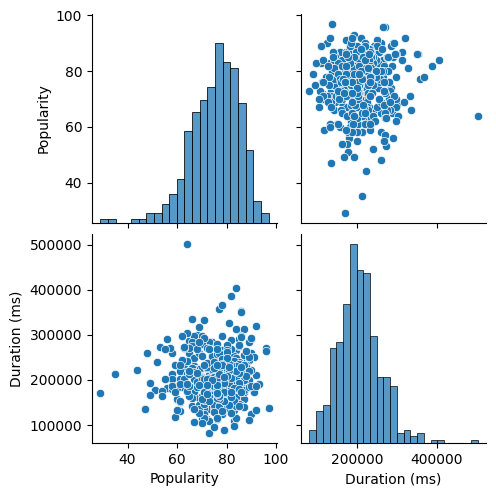

In [18]:
#8
# Pair plot of numerical variables
sns.pairplot(df_spotify_cleaned[['Popularity', 'Duration (ms)']])
plt.show()


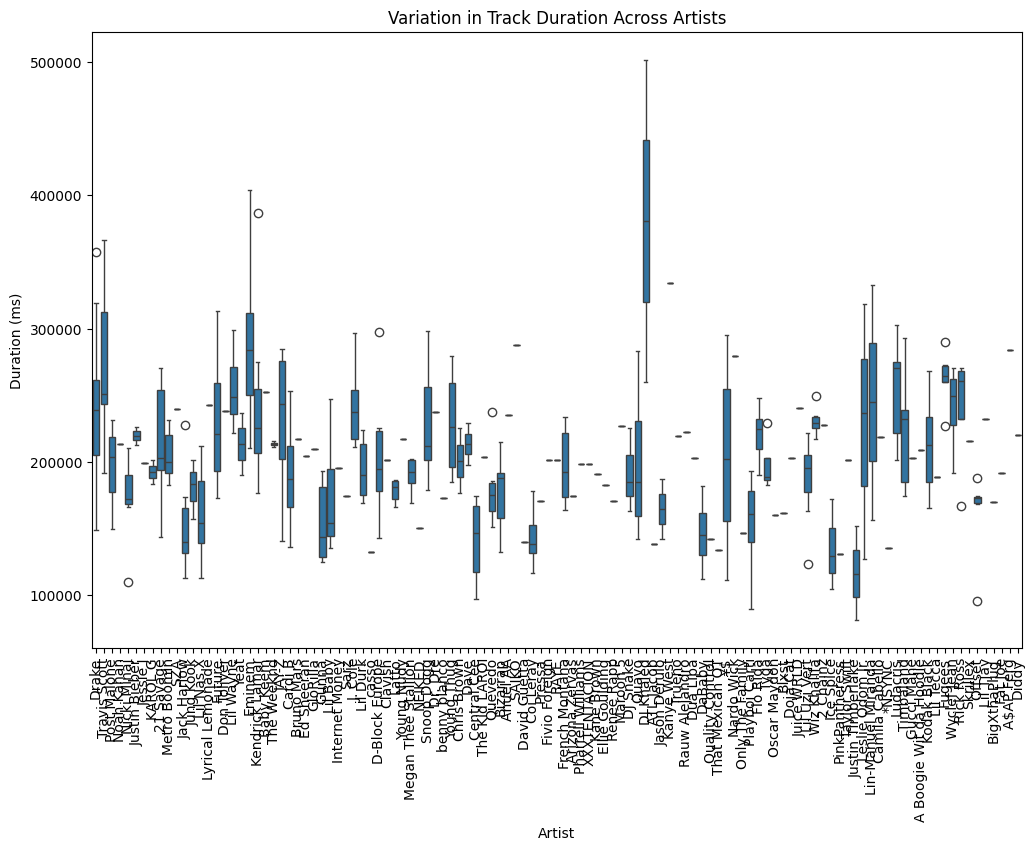

In [19]:
#9
# Box plot of track duration across artists
plt.figure(figsize=(12, 8))
sns.boxplot(x='Artist', y='Duration (ms)', data=df_spotify_cleaned)
plt.title('Variation in Track Duration Across Artists')
plt.xticks(rotation=90)
plt.show()


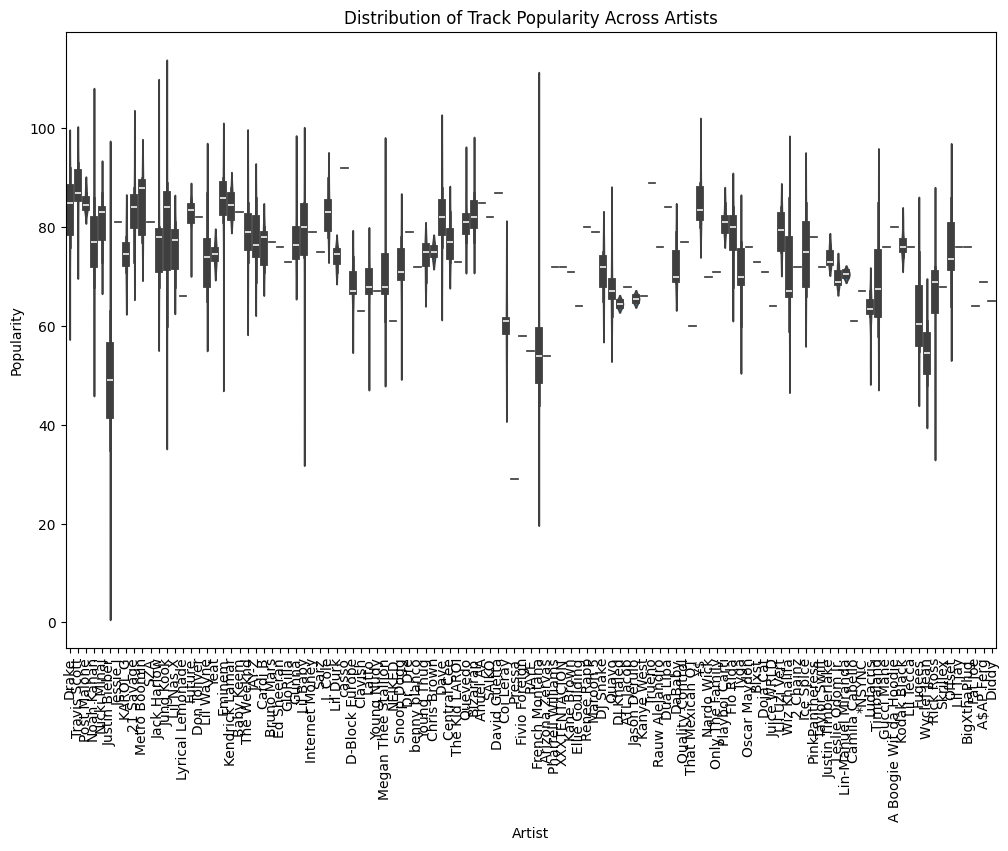

In [20]:
#10
# Violin plot of track popularity across artists
plt.figure(figsize=(12, 8))
sns.violinplot(x='Artist', y='Popularity', data=df_spotify_cleaned)
plt.title('Distribution of Track Popularity Across Artists')
plt.xticks(rotation=90)
plt.show()
